In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset('kang_15K_pbmc_rnaseq', save_path='scarf_datasets', as_zarr=True)
scarf.fetch_dataset('kang_14K_ifnb-pbmc_rnaseq', save_path='scarf_datasets', as_zarr=True)

ds_ctrl = scarf.DataStore('scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr', nthreads=4)
ds_stim = scarf.DataStore('scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr', nthreads=4)

merged = 'scarf_datasets/kang_merged_pbmc_rnaseq.zarr'
scarf.AssayMerge(
    zarr_path=merged,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    prepend_text='orig',
    reset_cell_filter=False,
    source_column='sample_id',
    overwrite=True,
).dump()

ds = scarf.DataStore(merged, nthreads=4)
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_leiden_clustering(resolution=0.5)
ds.run_umap(n_epochs=100, parallel=True)

Minimum cell count (562) is lower than size factor multiplier (1000)



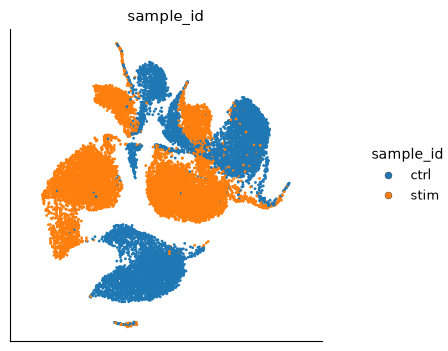

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [2]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='sample_id',
)

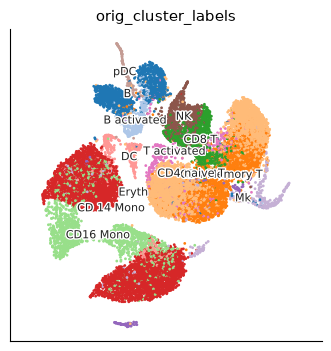

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='orig_cluster_labels',
)

In [4]:
lisi = ds.metric_lisi(label_colnames=['sample_id'])
lisi

Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



[('sample_id',
  array([1.        , 1.        , 1.00394119, ..., 1.50384306, 1.        ,
         1.        ], shape=(18598,)))]

In [5]:
ds.metric_batch_mixing(label_colname='sample_id')

Perplexity 30 requires at least 90 neighbors, but the graph has 11. Using perplexity 3.66667.



0.026415037993844228

In [6]:
ds.metric_silhouette(res_label='leiden_cluster')

array([ 0.31807888,  0.24689021,  0.46274389,  0.53893751,  0.29673567,
        0.0126618 ,  0.29100637,  0.4155761 ,  0.21569823, -0.24992647,
       -0.38269723,  0.5202051 ,  0.50791001])

In [7]:
ds.metric_label_concordance(
    label_columns=['RNA_leiden_cluster', 'orig_cluster_labels']
)

0.8121083059673978